<div style="display: flex; justify-content: space-around; gap: 10px; margin-bottom: 20px;">
    <img src="images/sun_earth.jpg" style="width: 48%; border-radius: 10px; object-fit: cover; height: 250px;">
    <img src="images/aurora.jpg" style="width: 48%; border-radius: 10px; object-fit: cover; height: 250px;">
</div>

# Phase 1 – Exploration & Validation du Dataset
## Projet ML : Prédiction des Tempêtes Géomagnétiques

**Réalisé par :** 
- AMEZIANE Oumaima
- ROHAND Douae
- MOHITO Raihana
  
**Date :** 2025-2026  
**Cours :** Machine Learning – 2ème année Cycle Ingénieurs GI  
**Encadrant :** Pr. Y. EL YOUNOUSSI

---

**Objectif de ce notebook :**  
Valider que le dataset construit respecte toutes les contraintes imposées pour la Phase 1 :
-  Taille ≥ 10 000 lignes
-  Nombre de features ≥ 8
-  Classe minoritaire entre 5 % et 25 %
-  Mix de variables numériques et catégorielles

## 0. Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style global des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Couleurs projet (thème aurore boréale)
COLOR_STORM   = '#00e5ff'   # cyan – classe tempête
COLOR_CALM    = '#1a237e'   # bleu nuit – classe calme
COLOR_ACCENT  = '#76ff03'   # vert aurore

## 1. Chargement du Dataset

In [2]:
df = pd.read_csv('../data/dataset.csv')
print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Dataset chargé : 43,207 lignes × 15 colonnes


## 2. Vue sur les 5 premier lignes du dataset 

In [3]:
df.head()

,timestamp,solar_wind_speed,solar_wind_density,bz_component,solar_wind_pressure,bz_min_3h,dst_index,month,sin_month,cos_month,season,hour_interval,bz_negative,is_solar_maximum,is_storm
0,2019-01-01 08:00:00,459.0,4.0,1.9,842724.0,-1.0,-9.0,1,0.5,0.866025,hiver,6h-9h,0.0,0,0
1,2019-01-01 09:00:00,453.0,4.5,2.5,923440.5,-1.0,-7.0,1,0.5,0.866025,hiver,9h-12h,0.0,0,0
2,2019-01-01 10:00:00,446.0,5.2,-0.1,1034363.2,-0.1,-4.0,1,0.5,0.866025,hiver,9h-12h,1.0,0,0
3,2019-01-01 11:00:00,438.0,4.6,-3.4,882482.4,-3.4,-9.0,1,0.5,0.866025,hiver,9h-12h,1.0,0,0
4,2019-01-01 12:00:00,433.0,4.3,-3.4,806202.7,-3.4,-12.0,1,0.5,0.866025,hiver,12h-15h,1.0,0,0


## 3. Vue d'ensemble : `df.info()`

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43207 entries, 0 to 43206
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            43207 non-null  str    
 1   solar_wind_speed     43207 non-null  float64
 2   solar_wind_density   43207 non-null  float64
 3   bz_component         43207 non-null  float64
 4   solar_wind_pressure  43207 non-null  float64
 5   bz_min_3h            43207 non-null  float64
 6   dst_index            43207 non-null  float64
 7   month                43207 non-null  int64  
 8   sin_month            43207 non-null  float64
 9   cos_month            43207 non-null  float64
 10  season               43207 non-null  str    
 11  hour_interval        43207 non-null  str    
 12  bz_negative          43207 non-null  float64
 13  is_solar_maximum     43207 non-null  int64  
 14  is_storm             43207 non-null  int64  
dtypes: float64(9), int64(3), str(3)
memory usage: 6

## 4. Statistiques descriptives : `df.describe()`

In [5]:
df.describe()

,solar_wind_speed,solar_wind_density,bz_component,solar_wind_pressure,bz_min_3h,dst_index,month,sin_month,cos_month,bz_negative,is_solar_maximum,is_storm
count,43207.000000,43207.000000,43207.000000,4.320700e+04,43207.000000,43207.000000,43207.000000,4.320700e+04,4.320700e+04,43207.000000,43207.000000,43207.000000
mean,410.103502,6.190365,-0.130196,9.489742e+05,-1.247830,-8.622052,6.525517,-4.955405e-03,-1.558478e-03,0.525771,0.399519,0.084107
std,86.251157,4.733501,2.756907,6.644353e+05,2.613833,14.622127,3.447336,7.068398e-01,7.073710e-01,0.499341,0.489805,0.277551
min,259.000000,0.100000,-32.400000,1.857610e+04,-32.400000,-213.000000,1.000000,-1.000000e+00,-1.000000e+00,0.000000,0.000000,0.000000
25%,344.000000,3.200000,-1.600000,5.628777e+05,-2.500000,-15.000000,4.000000,-8.660254e-01,-8.660254e-01,0.000000,0.000000,0.000000
50%,391.000000,4.900000,-0.200000,7.879896e+05,-1.200000,-6.000000,7.000000,-2.449294e-16,-1.836970e-16,1.000000,0.000000,0.000000
75%,461.000000,7.700000,1.200000,1.126735e+06,0.100000,0.000000,10.000000,5.000000e-01,8.660254e-01,1.000000,1.000000,0.000000
max,846.000000,84.400000,31.300000,1.211050e+07,27.500000,42.000000,12.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000


## 5. Validation des Contraintes du Projet

### 5.1 – Contrainte 1 : Taille ≥ 10 000 lignes

In [6]:
n_rows = df.shape[0]
seuil_lignes = 10_000

statut = 'VALIDÉE' if n_rows >= seuil_lignes else ' NON VALIDÉE'
print(f'Contrainte 1 — Nombre de lignes : {n_rows:,} (seuil : {seuil_lignes:,}) → {statut}')

Contrainte 1 — Nombre de lignes : 43,207 (seuil : 10,000) → VALIDÉE


### 5.2 – Contrainte 2 : Nombre de features ≥ 8

In [7]:
# On exclut la colonne cible du comptage des features
TARGET = 'is_storm'
features = [c for c in df.columns if c != TARGET]
n_features = len(features)
seuil_features = 8

statut = ' VALIDÉE' if n_features >= seuil_features else ' NON VALIDÉE'
print(f'Contrainte 2 — Nombre de features : {n_features} (seuil : {seuil_features}) → {statut}')
print(f'\nListe des features : {features}')

Contrainte 2 — Nombre de features : 14 (seuil : 8) →  VALIDÉE

Liste des features : ['timestamp', 'solar_wind_speed', 'solar_wind_density', 'bz_component', 'solar_wind_pressure', 'bz_min_3h', 'dst_index', 'month', 'sin_month', 'cos_month', 'season', 'hour_interval', 'bz_negative', 'is_solar_maximum']


### 5.3 – Contrainte 3 : Mix de variables numériques et catégorielles

In [8]:
numeriques   = df[features].select_dtypes(include=['number']).columns.tolist()
categorielles = df[features].select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f'Variables numériques  ({len(numeriques)}) : {numeriques}')
print(f'Variables catégorielles ({len(categorielles)}) : {categorielles}')

statut = ' VALIDÉE' if (len(numeriques) > 0 and len(categorielles) > 0) else ' NON VALIDÉE'
print(f'\nContrainte 3 — Mix num./cat. → {statut}')

Variables numériques  (11) : ['solar_wind_speed', 'solar_wind_density', 'bz_component', 'solar_wind_pressure', 'bz_min_3h', 'dst_index', 'month', 'sin_month', 'cos_month', 'bz_negative', 'is_solar_maximum']
Variables catégorielles (3) : ['timestamp', 'season', 'hour_interval']

Contrainte 3 — Mix num./cat. →  VALIDÉE


### 5.4 – Contrainte 4 : Déséquilibre de classe (5 % – 25 %)

In [9]:
counts    = df[TARGET].value_counts()
pct_storm = counts[1] / counts.sum() * 100
pct_calm  = counts[0] / counts.sum() * 100

print('=== Distribution de la variable cible `is_storm` ===')
print(f'  Classe 0 – Calme   : {counts[0]:>7,} échantillons  ({pct_calm:.2f} %)')
print(f'  Classe 1 – Tempête : {counts[1]:>7,} échantillons  ({pct_storm:.2f} %)')
print(f'  Ratio déséquilibre : 1:{counts[0]/counts[1]:.1f}')

statut = 'VALIDÉE' if 5 <= pct_storm <= 25 else 'NON VALIDÉE'
print(f'\nContrainte 4 — Classe minoritaire à {pct_storm:.2f} % (seuil : 5 %–25 %) → {statut}')

=== Distribution de la variable cible `is_storm` ===
  Classe 0 – Calme   :  39,573 échantillons  (91.59 %)
  Classe 1 – Tempête :   3,634 échantillons  (8.41 %)
  Ratio déséquilibre : 1:10.9

Contrainte 4 — Classe minoritaire à 8.41 % (seuil : 5 %–25 %) → VALIDÉE


## 6. Visualisations du Déséquilibre de Classe

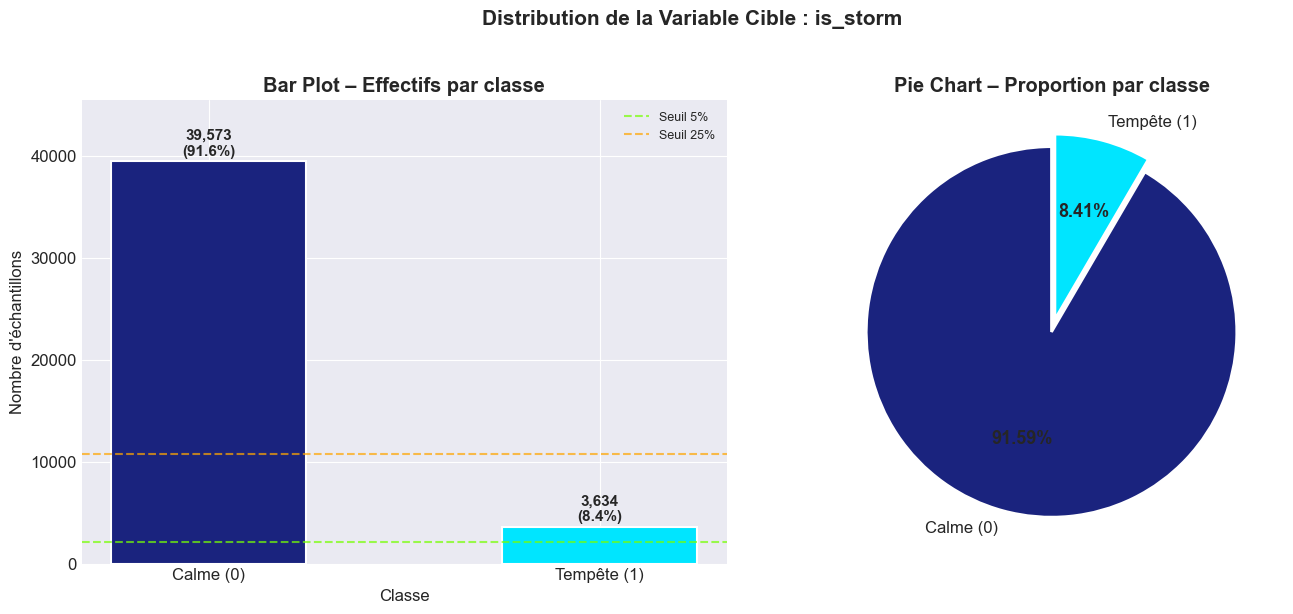

Figure sauvegardée → data/class_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution de la Variable Cible : is_storm', fontsize=15, fontweight='bold', y=1.02)

labels = ['Calme (0)', 'Tempête (1)']
values = [counts[0], counts[1]]
colors = [COLOR_CALM, COLOR_STORM]

# --- Bar Plot ---
bars = axes[0].bar(labels, values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Bar Plot – Effectifs par classe', fontweight='bold')
axes[0].set_ylabel('Nombre d\'échantillons')
axes[0].set_xlabel('Classe')
for bar, val, pct in zip(bars, values, [pct_calm, pct_storm]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{val:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontweight='bold', fontsize=11
    )
axes[0].set_ylim(0, max(values) * 1.15)

# Zone de déséquilibre accepté
axes[0].axhline(y=counts.sum() * 0.05, color=COLOR_ACCENT, linestyle='--', alpha=0.7, label='Seuil 5%')
axes[0].axhline(y=counts.sum() * 0.25, color='orange', linestyle='--', alpha=0.7, label='Seuil 25%')
axes[0].legend(fontsize=9)

# --- Pie Chart ---
wedges, texts, autotexts = axes[1].pie(
    values,
    labels=labels,
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.07),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(13)
axes[1].set_title('Pie Chart – Proportion par classe', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → data/class_distribution.png')

## 7. Exploration des Features

### 7.1 – Valeurs manquantes

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valeurs manquantes': missing, '% du total': missing_pct})
missing_df = missing_df[missing_df['Valeurs manquantes'] > 0].sort_values('% du total', ascending=False)

if missing_df.empty:
    print(' Aucune valeur manquante détectée.')
else:
    print(f'{len(missing_df)} colonnes avec des valeurs manquantes :')
    display(missing_df)

 Aucune valeur manquante détectée.


### 7.2 – Distribution des features numériques

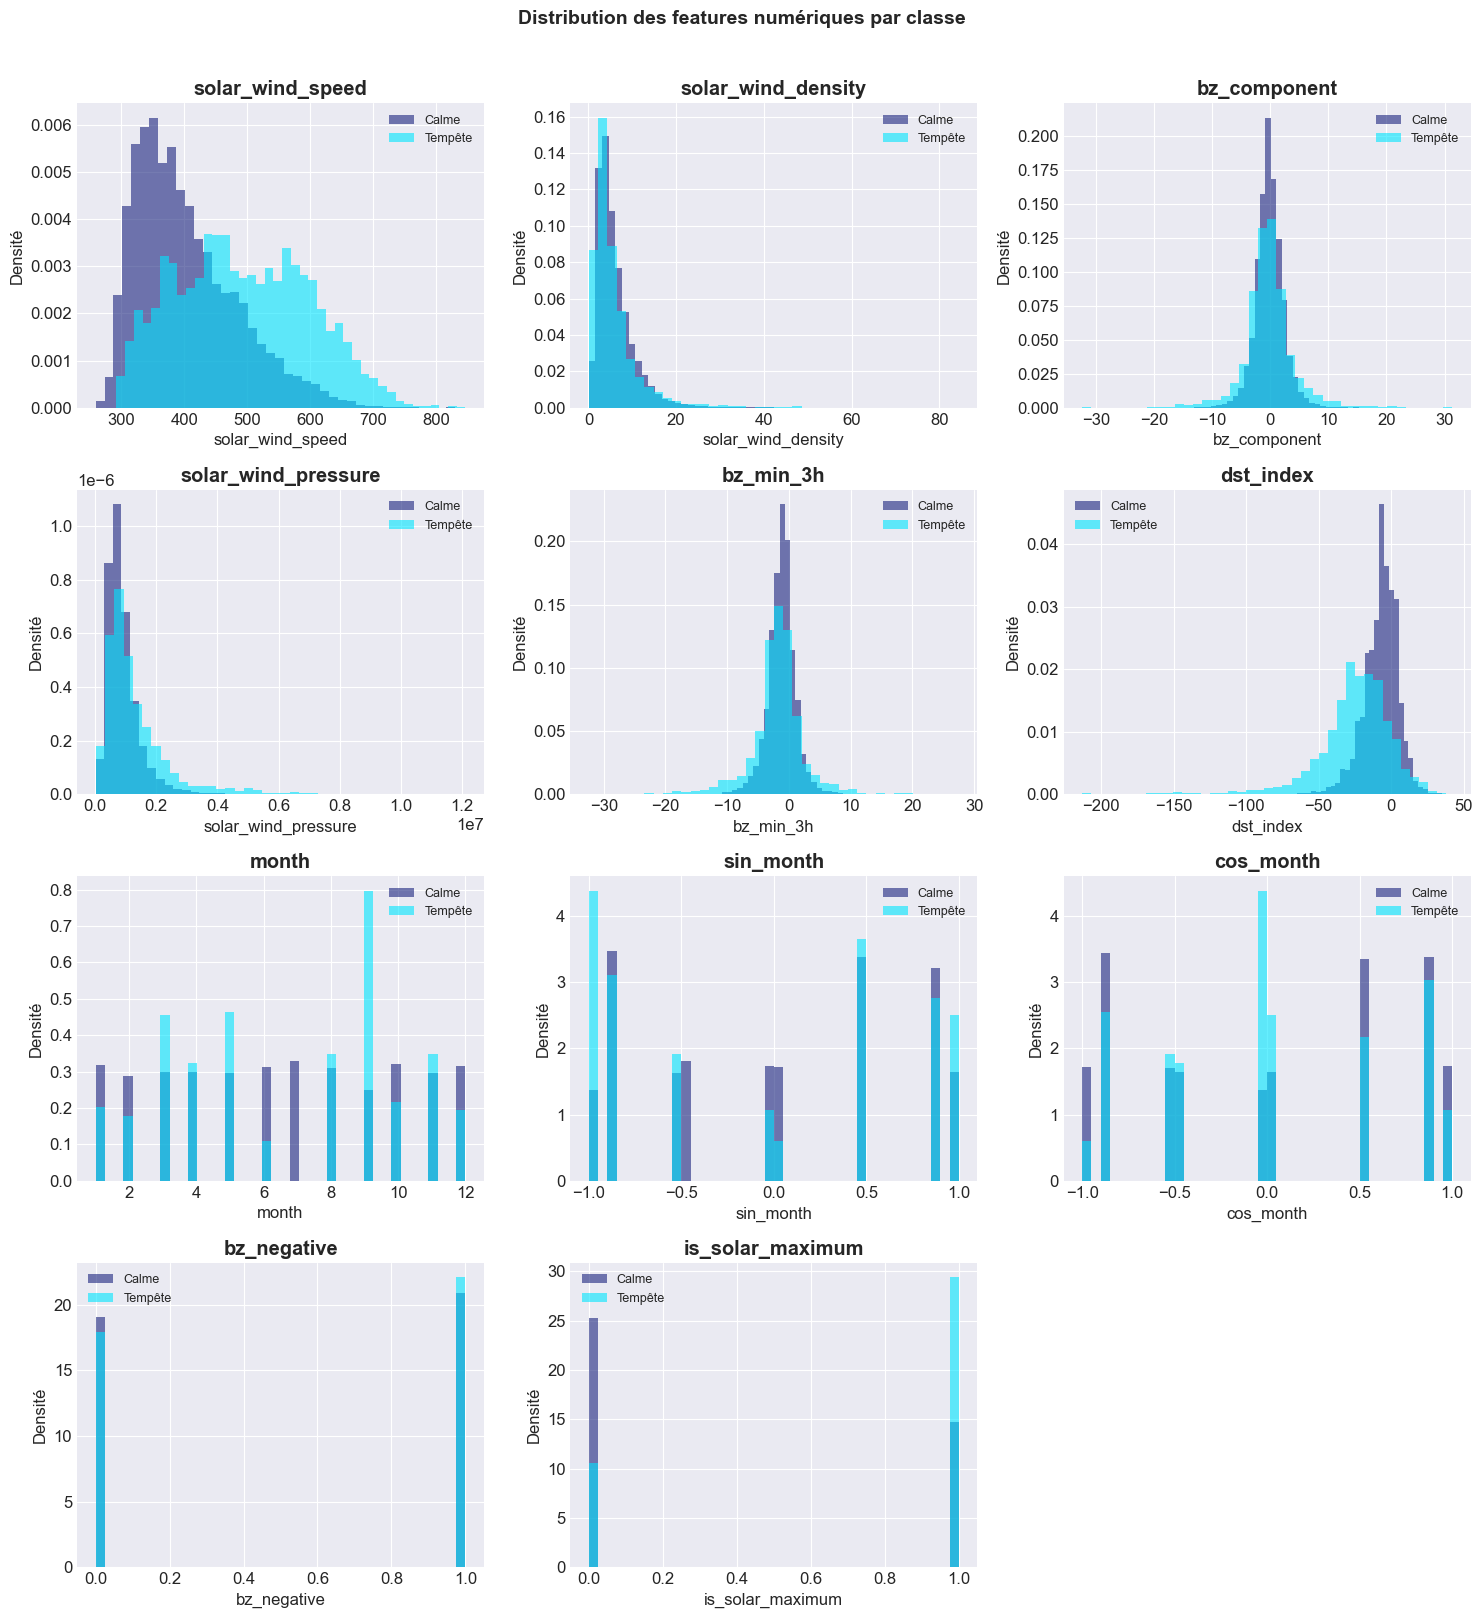

In [12]:
if numeriques:
    n_cols = 3
    n_rows_plot = (len(numeriques) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows_plot, n_cols, figsize=(15, 4 * n_rows_plot))
    axes = axes.flatten() if n_rows_plot > 1 else [axes] if len(numeriques) == 1 else axes.flatten()

    for i, col in enumerate(numeriques):
        for val, color, label in zip([0, 1], [COLOR_CALM, COLOR_STORM], ['Calme', 'Tempête']):
            axes[i].hist(
                df[df[TARGET] == val][col].dropna(),
                bins=40, alpha=0.6, color=color, label=label, density=True
            )
        axes[i].set_title(col, fontweight='bold')
        axes[i].legend(fontsize=9)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Densité')

    # Cacher les axes vides
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribution des features numériques par classe', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

### 7.3 – Distribution des features catégorielles

In [ ]:
if categorielles:
    n_cols = 2
    n_rows_plot = (len(categorielles) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows_plot, n_cols, figsize=(14, 4 * n_rows_plot))
    axes = np.array(axes).flatten()

    for i, col in enumerate(categorielles):
        ct = pd.crosstab(df[col], df[TARGET])
        ct.columns = ['Calme', 'Tempête']
        ct.plot(kind='bar', ax=axes[i], color=[COLOR_CALM, COLOR_STORM],
                edgecolor='white', width=0.7)
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Effectifs')
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].legend(fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribution des features catégorielles par classe', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Aucune feature catégorielle détectée automatiquement.')
    print('Vérifiez manuellement les colonnes : month, season, hour_interval, bz_negative, is_solar_maximum')

### 7.4 – Matrice de corrélation (features numériques)

In [ ]:
if len(numeriques) >= 2:
    corr_matrix = df[numeriques + [TARGET]].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, linewidths=0.5,
        ax=ax, square=True
    )
    ax.set_title('Matrice de corrélation (features numériques + cible)', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

## 8. Résumé de Validation – Tableau de Bord Final

In [ ]:
checks = {
    'Taille ≥ 10 000 lignes'                    : (df.shape[0] >= 10_000,    f'{df.shape[0]:,} lignes'),
    'Features ≥ 8'                               : (n_features >= 8,          f'{n_features} features'),
    'Variables numériques présentes'             : (len(numeriques) > 0,      f'{len(numeriques)} num.'),
    'Variables catégorielles présentes'          : (len(categorielles) > 0,   f'{len(categorielles)} cat.'),
    'Classe minoritaire entre 5 % et 25 %'       : (5 <= pct_storm <= 25,     f'{pct_storm:.2f} %'),
    'Aucune valeur manquante (ou gérée)'         : (missing.sum() == 0,       f'{int(missing.sum())} NaN'),
}

print('=' * 65)
print(f'{"TABLEAU DE BORD – VALIDATION DU DATASET":^65}')
print('=' * 65)
all_ok = True
for critere, (ok, valeur) in checks.items():
   
    print(f'  {icone}  {critere:<42}  [{valeur}]')
    if not ok:
        all_ok = False
print('=' * 65)

if all_ok:
    print('\n Toutes les contraintes sont validées. Dataset EXPLOITABLE.')
else:
    print('\n Une ou plusieurs contraintes ne sont pas respectées.')